# EDA — PPE Safety Detection Dataset

This notebook explores the dataset before we start training. The goals are:
- Basic health check on the dataset (image counts, class counts)
- Check for class imbalance (are helmet vs no-helmet images roughly balanced, or is one class underrepresented)
- Visually verify bounding box labels (confirm boxes are placed correctly)

This step matters because catching data issues (missing labels, wrong annotations, severe imbalance) *before* training is much easier than debugging a poorly-performing model after the fact.

## 1. Setup — Load Config and Class Names

The dataset from Roboflow includes a `data.yaml` file that defines the class names (helmet, no-helmet, person). This cell parses that config to load the class list — so we avoid hardcoding class names, and if classes ever change, we only need to update the yaml file.

In [1]:
import yaml
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

DATA_ROOT = Path("../data/raw")

# Load class names from data.yaml
with open(DATA_ROOT / "data.yaml", "r") as f:
    data_config = yaml.safe_load(f)

class_names = data_config["names"]
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

Classes: ['head', 'helmet', 'person']
Number of classes: 3


## 2. Image Count per Split

This checks how many images exist in each split (train/valid/test). This matters because:
- If a split accidentally ended up empty (e.g. a mistake while creating the validation split), it will show up here
- The total should match the 7035 images shown on the Roboflow dataset page — if it doesn't, some images went missing somewhere

In [2]:
splits = ["train", "valid", "test"]
counts = {}

for split in splits:
    img_dir = DATA_ROOT / split / "images"
    count = len(list(img_dir.glob("*.*")))
    counts[split] = count
    print(f"{split}: {count} images")

print(f"\nTotal: {sum(counts.values())} images")

train: 4479 images
valid: 790 images
test: 1766 images

Total: 7035 images


## 3. Class Distribution — Bounding Box Instance Counts

Each image can contain multiple bounding boxes (e.g. one image might show 3 people, 2 wearing helmets and 1 not). This cell counts **instances** (individual bounding boxes), not images — i.e., how many total "helmet" labels exist, how many "no-helmet" labels exist, and so on.

This gives us a sense of class imbalance — if "no-helmet" instances are much rarer than "helmet" instances, we'll need to account for that during training (e.g. weighted loss, or targeted augmentation on the minority class).

In [3]:
def count_class_instances(labels_dir: Path, class_names: list) -> Counter:
    counter = Counter()
    for label_file in labels_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                class_id = int(line.split()[0])
                counter[class_names[class_id]] += 1
    return counter

train_labels_dir = DATA_ROOT / "train" / "labels"
class_counts = count_class_instances(train_labels_dir, class_names)

print("Class distribution in training set:")
for cls, count in class_counts.most_common():
    print(f"  {cls}: {count}")

Class distribution in training set:
  helmet: 12687
  head: 4188
  person: 402


## 4. Class Distribution — Bar Chart

Plotting the counts above as a bar chart to make the imbalance visually obvious. A chart is easier to read at a glance than raw numbers.

Whichever bar is noticeably shorter than the others is our minority class — that's the one we'll need to pay special attention to during training.

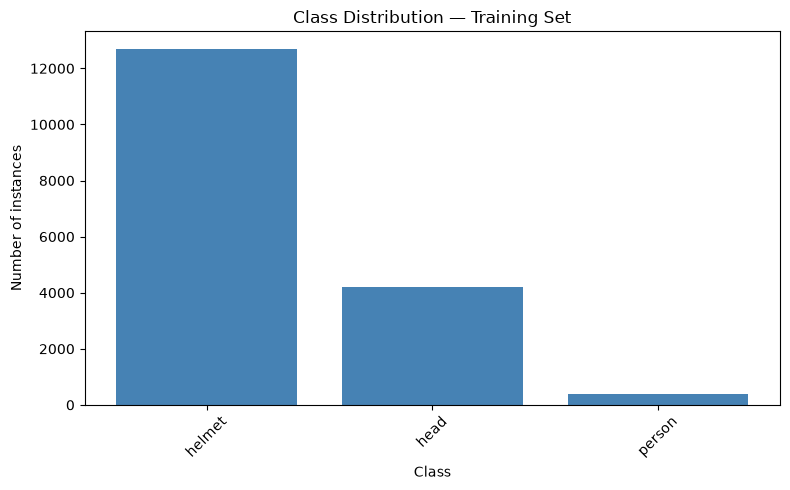

In [4]:
plt.figure(figsize=(8, 5))
classes = list(class_counts.keys())
counts_list = list(class_counts.values())

plt.bar(classes, counts_list, color="steelblue")
plt.title("Class Distribution — Training Set")
plt.xlabel("Class")
plt.ylabel("Number of instances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Sample Images with Bounding Boxes — Visual Label Verification

This is the most important sanity check. We take 6 random training images and draw their bounding boxes on top (converting YOLO's normalized coordinates into actual pixel coordinates).

**Why this matters:** dataset labels are sometimes wrong — a box might be in the wrong place, or assigned the wrong class. If we skip this check and go straight to training, the model will learn from bad labels and we won't know why performance is poor.

The `draw_boxes()` function converts YOLO's normalized format (x_center, y_center, width, height — all between 0 and 1) into pixel coordinates, then uses OpenCV to draw the box and class label on the image.

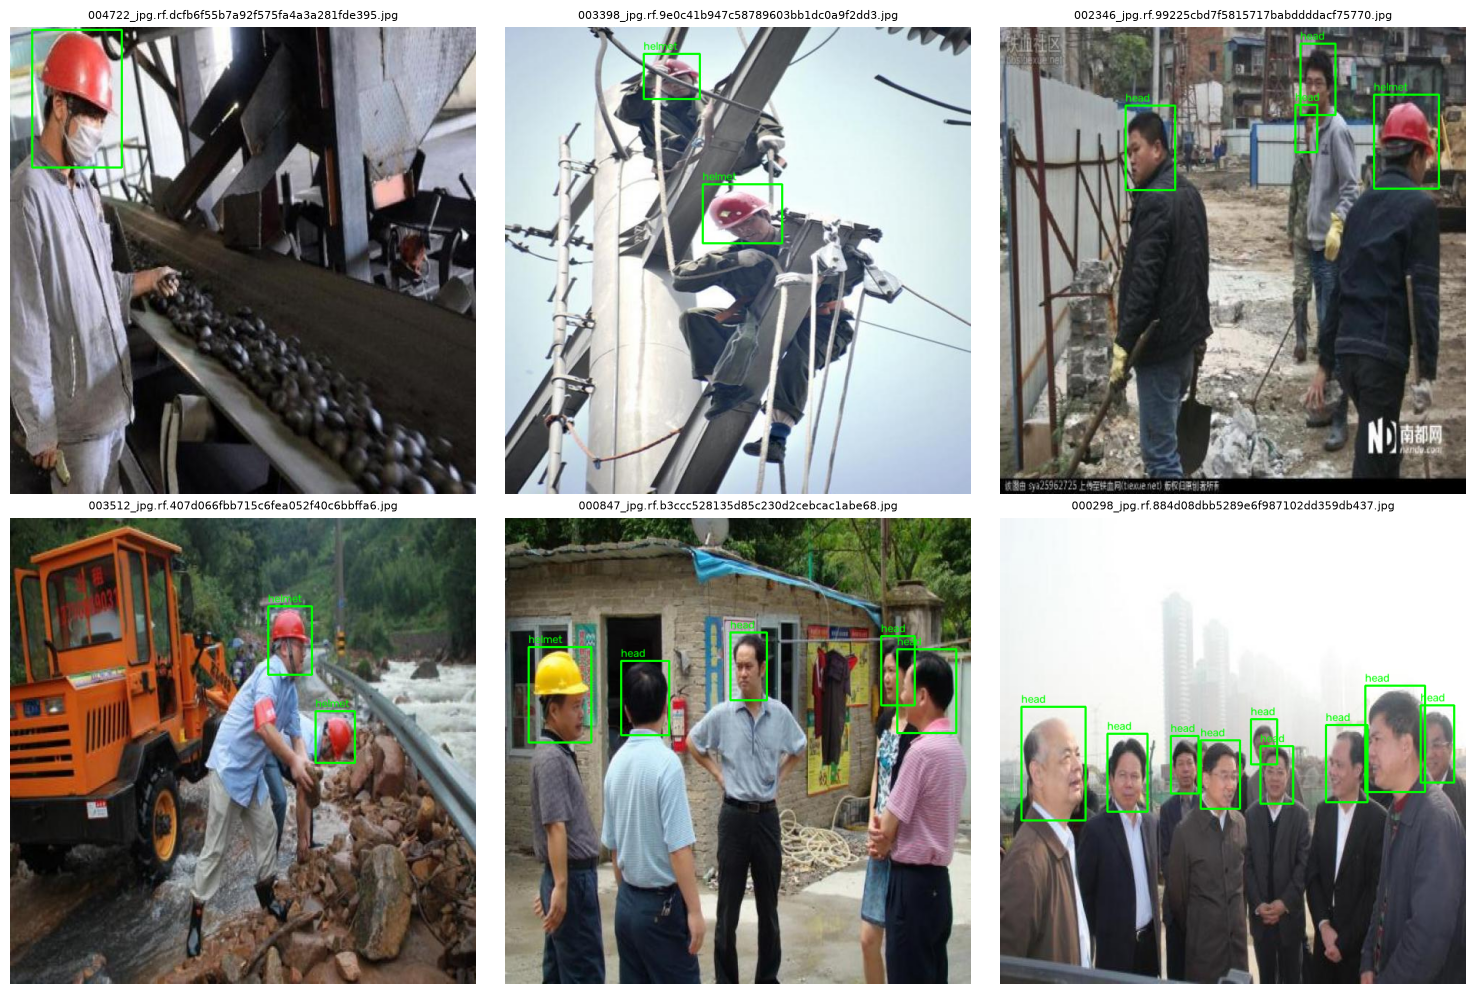

In [5]:
import random

def draw_boxes(img_path: Path, label_path: Path, class_names: list):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                parts = line.split()
                cls_id = int(parts[0])
                x_center, y_center, bw, bh = map(float, parts[1:5])

                # YOLO format (normalized) -> pixel coords
                x1 = int((x_center - bw / 2) * w)
                y1 = int((y_center - bh / 2) * h)
                x2 = int((x_center + bw / 2) * w)
                y2 = int((y_center + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, class_names[cls_id], (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


train_images_dir = DATA_ROOT / "train" / "images"
train_labels_dir = DATA_ROOT / "train" / "labels"

all_images = list(train_images_dir.glob("*.*"))
sample_images = random.sample(all_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), sample_images):
    label_path = train_labels_dir / (img_path.stem + ".txt")
    img_with_boxes = draw_boxes(img_path, label_path, class_names)
    ax.imshow(img_with_boxes)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Findings Summary

**Dataset size:**
- Total images: 7,035 (Train: ~4,479 | Valid: ~790 | Test: 1,766)

**Class distribution (training set, instance counts):**
- helmet: 12,687
- head (no-helmet): 4,188
- person: 402

**Class imbalance — key finding:**
The dataset shows severe class imbalance. The `helmet` class has ~3x more instances than `head`, and ~31x more than `person`. This is a critical issue because `head` (no-helmet) represents the actual safety violation we care about detecting — the class the business use case depends on most is also the most underrepresented. Without correction, the model is likely to perform well on `helmet` detection but underperform on `head` and `person`, potentially missing real safety violations.

**Label quality:**
Visual inspection of sample images with drawn bounding boxes confirmed that labels are correctly placed and aligned with the corresponding objects — no obvious annotation errors observed in the sampled images.

**Next steps (to address in the training pipeline):**
1. Apply class-weighted loss during training to upweight `head` and `person`.
2. Use targeted augmentation on images containing minority classes (`head`, `person`) to effectively increase their representation.
3. Evaluate using per-class metrics (precision/recall/mAP for each class individually), not just overall mAP — overall mAP can look good while the minority class (the one that matters most) still performs poorly.
4. Consider whether the `person` class is necessary for the core use case (helmet compliance), or whether it can be dropped to simplify the problem and reduce label noise from an underrepresented class.